In [80]:
import sys
sys.path.append("..")

# Reload modules in /src/ when changed
%load_ext autoreload
%autoreload 2

from fxml.data.labeling.barrier_method import BarrierMethod

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
# plt.rcParams["figure.figsize"] = (12, 2)
import seaborn as sns
sns.set(style="ticks", palette="tab10")

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [81]:
data = pd.read_pickle('../data/processed/USDJPY-15m-20240101-20241231_FEATURES.pkl')

In [82]:
horizons = pd.read_pickle('../data/predictions/test_t2v_transformer_regr_h1.pkl')

In [83]:
data = data.join(horizons, how='left')

In [84]:
data.dropna(inplace=True)

In [125]:
list(data.columns)

['open',
 'high',
 'low',
 'close',
 'volume',
 'spread',
 'tick',
 'log_volume',
 'o_c_diff',
 'o_h_diff',
 'o_l_diff',
 'close_pct_return',
 'close_return',
 'close_log_return',
 'close_fd_return',
 'close_log_fd_return',
 'SMA_5',
 'SMA_9',
 'SMA_20',
 'SMA_24',
 'SMA_36',
 'SMA_50',
 'SMA_100',
 'EMA_5',
 'EMA_5_slope',
 'close_to_EMA_5',
 'EMA_9',
 'EMA_9_slope',
 'close_to_EMA_9',
 'EMA_20',
 'EMA_20_slope',
 'close_to_EMA_20',
 'EMA_24',
 'EMA_24_slope',
 'close_to_EMA_24',
 'EMA_36',
 'EMA_36_slope',
 'close_to_EMA_36',
 'EMA_50',
 'EMA_50_slope',
 'close_to_EMA_50',
 'EMA_100',
 'EMA_100_slope',
 'close_to_EMA_100',
 'ATRr_14',
 'ATRr_60',
 'ATRr_120',
 'ATRr_200',
 'ADX_5',
 'ADXR_5_2',
 'DMP_5',
 'DMN_5',
 'ADX_10',
 'ADXR_10_2',
 'DMP_10',
 'DMN_10',
 'ADX_15',
 'ADXR_15_2',
 'DMP_15',
 'DMN_15',
 'ADX_20',
 'ADXR_20_2',
 'DMP_20',
 'DMN_20',
 'ADX_25',
 'ADXR_25_2',
 'DMP_25',
 'DMN_25',
 'ADX_30',
 'ADXR_30_2',
 'DMP_30',
 'DMN_30',
 'ADX_36',
 'ADXR_36_2',
 'DMP_36',
 'D

In [ ]:
data['pred_r'] = data['h0'] - data['close']

# data['signal'] = data['pred_r'].apply(lambda x: 1 if x>0 else 0)
data['signal'] = np.sign(data['pred_r'])

data['r'] = np.log(data['close']).diff().shift(-1)
strat_r = data['signal'] * data['r']

In [94]:
pf = strat_r[strat_r > 0].sum() / strat_r[strat_r < 0].abs().sum() 
print("Profit Factor", pf)

Profit Factor 1.048940082531513


In [108]:
sharpe = strat_r.mean() / strat_r.std() * np.sqrt(data.shape[0])
print("Sharpe Ratio", sharpe)

Sharpe Ratio 2.1750596634108486


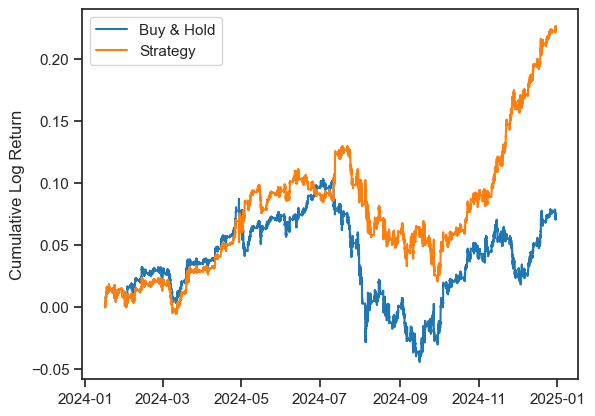

In [106]:
bh = data['r'].cumsum()
plt.plot(bh, label="Buy & Hold")
plt.plot(strat_r.cumsum(), label="Strategy")
plt.ylabel("Cumulative Log Return")
plt.legend()
plt.show()

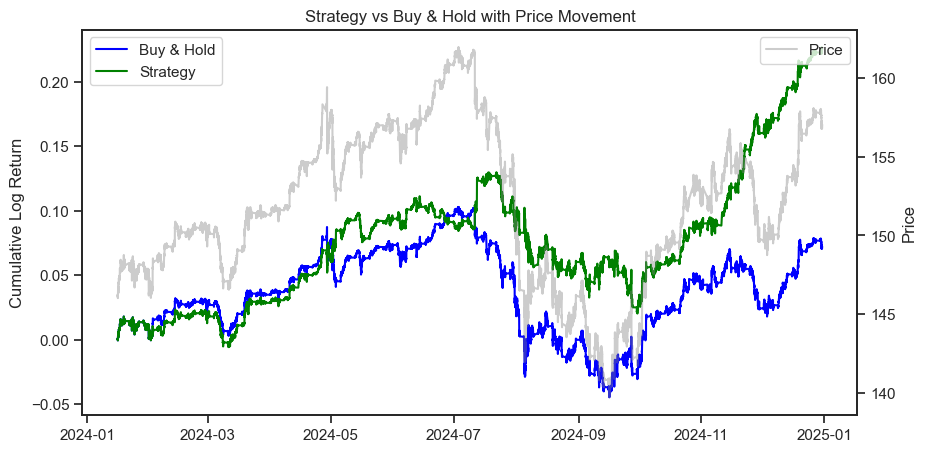

In [111]:
fig, ax1 = plt.subplots(figsize=(10, 5))

# ---- Left axis: cumulative log returns ----
bh = data['r'].cumsum()
ax1.plot(bh, label="Buy & Hold", color='blue')
ax1.plot(strat_r.cumsum(), label="Strategy", color='green')
ax1.set_ylabel("Cumulative Log Return")
ax1.legend(loc="upper left")

# ---- Right axis: price series ----
ax2 = ax1.twinx()
ax2.plot(data['close'], label="Price", color='grey', alpha=0.4)
ax2.set_ylabel("Price")

# Optional: Price legend on right side
ax2.legend(loc="upper right")

plt.title("Strategy vs Buy & Hold with Price Movement")
plt.show()


In [120]:
side_df = data[['h0', 'signal', 'pred_r']].copy()

In [121]:
side_df

,h0,signal,pred_r
timestamp,,,
2024-01-16 05:00:00,146.613617,1.0,0.518617
2024-01-16 05:15:00,146.609039,1.0,0.490539
2024-01-16 05:30:00,146.631714,1.0,0.369214
2024-01-16 05:45:00,146.635834,1.0,0.469334
2024-01-16 06:00:00,146.661072,1.0,0.464572
...,...,...,...
2024-12-30 22:30:00,156.637573,-1.0,-0.279927
2024-12-30 22:45:00,156.623459,-1.0,-0.266541
2024-12-30 23:00:00,156.619553,-1.0,-0.400947


In [123]:
side_df.to_pickle('../data/sides/t2v_xfmr_regr_strategy.pkl')